# Baseline MLP sobre embeddings de CLIP

Este notebook establece un modelo de referencia sencillo y reproducible. Concatena los embeddings visual y textual de CLIP (512 + 512 = 1024) y entrena únicamente un MLP para predecir una acción de ocho componentes. No se busca optimizar al máximo el rendimiento, sino obtener un punto de comparación razonable para el futuro Transformer de fusión.

## 1. Configuración e imports

Se reutiliza la semilla 42 de los notebooks anteriores. El notebook trabaja directamente con el caché generado por `04_clip_embeddings`, sin cargar imágenes ni vídeos.

In [1]:
from pathlib import Path
import json, os, random, sys, time
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

ROOT_DIR = Path(os.getcwd()).resolve().parent
if str(ROOT_DIR) not in sys.path: sys.path.append(str(ROOT_DIR))
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available(): torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True; torch.backends.cudnn.benchmark = False
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
CACHE_DIR = ROOT_DIR / 'data' / 'cache_embeddings'
IMAGES_DIR = ROOT_DIR / 'images'; RESULTS_DIR = ROOT_DIR / 'results'; CHECKPOINTS_DIR = ROOT_DIR / 'checkpoints'
for directory in (IMAGES_DIR, RESULTS_DIR, CHECKPOINTS_DIR): directory.mkdir(parents=True, exist_ok=True)
BATCH_SIZE = 128; LEARNING_RATE = 1e-3; EPOCHS = 25; DROPOUT = 0.10; NUM_WORKERS = 0
print(f'Dispositivo: {DEVICE} | semilla: {SEED}')
print(f'Caché: {CACHE_DIR}')

Dispositivo: cpu | semilla: 42
Caché: C:\TFM_Codigo\TFM-VLA\data\cache_embeddings


## 2. Carga de embeddings cacheados

Cada `.npz` contiene `imagenes`, `textos` y `acciones` para una partición. Se comprueba el formato y las dimensiones esperadas.

In [2]:
def cargar_particion(nombre):
    ruta = CACHE_DIR / f'{nombre}.npz'
    if not ruta.exists():
        raise FileNotFoundError(f'No existe {ruta}. Ejecuta primero 04_clip_embeddings.ipynb.')
    with np.load(ruta) as datos:
        requeridas = {'imagenes','textos','acciones'}
        if not requeridas.issubset(datos.files): raise KeyError(f'Claves esperadas: {requeridas}')
        visual = np.asarray(datos['imagenes'], dtype=np.float32)
        textual = np.asarray(datos['textos'], dtype=np.float32)
        acciones = np.asarray(datos['acciones'], dtype=np.float32)
    if not (visual.ndim == textual.ndim == acciones.ndim == 2): raise ValueError(f'{nombre}: arrays no 2D')
    if not (len(visual) == len(textual) == len(acciones)): raise ValueError(f'{nombre}: tamaños inconsistentes')
    if visual.shape[1] != 512 or textual.shape[1] != 512 or acciones.shape[1] != 8: raise ValueError(f'{nombre}: dimensiones inesperadas')
    return visual, textual, acciones
particiones = {n: cargar_particion(n) for n in ('train','validation','test')}
for n,(v,t,a) in particiones.items():
    print(f'{n:10s}: visual={v.shape}, textual={t.shape}, acciones={a.shape}')
    assert np.isfinite(v).all() and np.isfinite(t).all() and np.isfinite(a).all()

train     : visual=(190212, 512), textual=(190212, 512), acciones=(190212, 8)
validation: visual=(23760, 512), textual=(23760, 512), acciones=(23760, 8)
test      : visual=(23826, 512), textual=(23826, 512), acciones=(23826, 8)


## 3. Preparación del dataset

Se concatenan los embeddings manteniendo intactas las particiones train, validation y test.

In [3]:
def construir_entrada(datos):
    visual, textual, acciones = datos
    return np.concatenate([visual, textual], axis=1), acciones
entradas = {n: construir_entrada(d) for n,d in particiones.items()}
datasets = {n: TensorDataset(torch.from_numpy(x), torch.from_numpy(y)) for n,(x,y) in entradas.items()}
generator = torch.Generator().manual_seed(SEED)
loaders = {'train': DataLoader(datasets['train'], batch_size=BATCH_SIZE, shuffle=True, generator=generator, num_workers=NUM_WORKERS), 'validation': DataLoader(datasets['validation'], batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS), 'test': DataLoader(datasets['test'], batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)}
print({n: len(ds) for n,ds in datasets.items()}); print('Entrada:', entradas['train'][0].shape[1]); assert entradas['train'][0].shape[1] == 1024

{'train': 190212, 'validation': 23760, 'test': 23826}
Entrada: 1024


## 4. Modelo BaselineMLP y comprobación

La red sigue 1024 → 512 → 256 → 8, con ReLU y dropout entre capas ocultas.

In [4]:
class BaselineMLP(nn.Module):
    def __init__(self, input_dim=1024, hidden_dim_1=512, hidden_dim_2=256, output_dim=8, dropout=0.10):
        super().__init__()
        self.network = nn.Sequential(nn.Linear(input_dim, hidden_dim_1), nn.ReLU(), nn.Dropout(dropout), nn.Linear(hidden_dim_1, hidden_dim_2), nn.ReLU(), nn.Dropout(dropout), nn.Linear(hidden_dim_2, output_dim))
    def forward(self, x): return self.network(x)
model = BaselineMLP(dropout=DROPOUT).to(DEVICE)
x_batch,y_batch = next(iter(loaders['train']))
with torch.no_grad(): y_batch_pred = model(x_batch.to(DEVICE))
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print('Batch:', tuple(x_batch.shape), '| objetivo:', tuple(y_batch.shape), '| salida:', tuple(y_batch_pred.shape)); print(f'Parámetros entrenables: {num_params:,}')
assert y_batch_pred.shape[-1] == 8 and torch.isfinite(y_batch_pred).all()

Batch: (128, 1024) | objetivo: (128, 8) | salida: (128, 8)
Parámetros entrenables: 658,184


## 5. Entrenamiento

Se utiliza AdamW con MSELoss. El mejor modelo se guarda según `validation_loss`; test no participa en esta selección.

In [5]:
criterion = nn.MSELoss(); optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)
history=[]; best_val_loss=float('inf'); best_epoch=0; best_path=CHECKPOINTS_DIR/'baseline_mlp_best.pt'
training_start=time.perf_counter()
for epoch in range(1,EPOCHS+1):
    epoch_start=time.perf_counter(); model.train(); train_sum=train_count=0
    for features,targets in loaders['train']:
        features,targets=features.to(DEVICE),targets.to(DEVICE); optimizer.zero_grad(set_to_none=True); loss=criterion(model(features),targets); loss.backward(); optimizer.step(); train_sum+=loss.item()*len(features); train_count+=len(features)
    model.eval(); val_sum=val_count=0
    with torch.no_grad():
        for features,targets in loaders['validation']:
            features,targets=features.to(DEVICE),targets.to(DEVICE); val_sum+=criterion(model(features),targets).item()*len(features); val_count+=len(features)
    train_loss=train_sum/train_count; val_loss=val_sum/val_count; epoch_time=time.perf_counter()-epoch_start
    history.append({'epoch':epoch,'train_loss':train_loss,'validation_loss':val_loss,'time_epoch_seconds':epoch_time})
    if val_loss < best_val_loss:
        best_val_loss=val_loss; best_epoch=epoch; torch.save({'model_state_dict':model.state_dict(),'epoch':epoch,'validation_loss':val_loss},best_path)
    print(f'Epoch {epoch:02d}/{EPOCHS} | train_loss={train_loss:.6f} | validation_loss={val_loss:.6f} | {epoch_time:.1f}s')
total_training_time=time.perf_counter()-training_start; print(f'Tiempo total: {total_training_time:.2f}s | mejor época: {best_epoch}')

Epoch 01/25 | train_loss=0.033320 | validation_loss=0.030336 | 48.9s
Epoch 02/25 | train_loss=0.026732 | validation_loss=0.027177 | 40.6s
Epoch 03/25 | train_loss=0.023949 | validation_loss=0.028094 | 44.2s
Epoch 04/25 | train_loss=0.022513 | validation_loss=0.023974 | 33.0s
Epoch 05/25 | train_loss=0.021534 | validation_loss=0.023890 | 33.7s
Epoch 06/25 | train_loss=0.020560 | validation_loss=0.022992 | 32.4s
Epoch 07/25 | train_loss=0.019881 | validation_loss=0.023759 | 33.4s
Epoch 08/25 | train_loss=0.019272 | validation_loss=0.023036 | 30.3s
Epoch 09/25 | train_loss=0.018978 | validation_loss=0.025709 | 34.2s
Epoch 10/25 | train_loss=0.018605 | validation_loss=0.023050 | 30.1s
Epoch 11/25 | train_loss=0.018233 | validation_loss=0.022912 | 35.2s
Epoch 12/25 | train_loss=0.017940 | validation_loss=0.023143 | 35.6s
Epoch 13/25 | train_loss=0.017610 | validation_loss=0.022948 | 32.7s
Epoch 14/25 | train_loss=0.017317 | validation_loss=0.022784 | 34.4s
Epoch 15/25 | train_loss=0.017221 

## 6. Curvas de entrenamiento

Las curvas ayudan a comprobar la convergencia y a identificar sobreajuste.

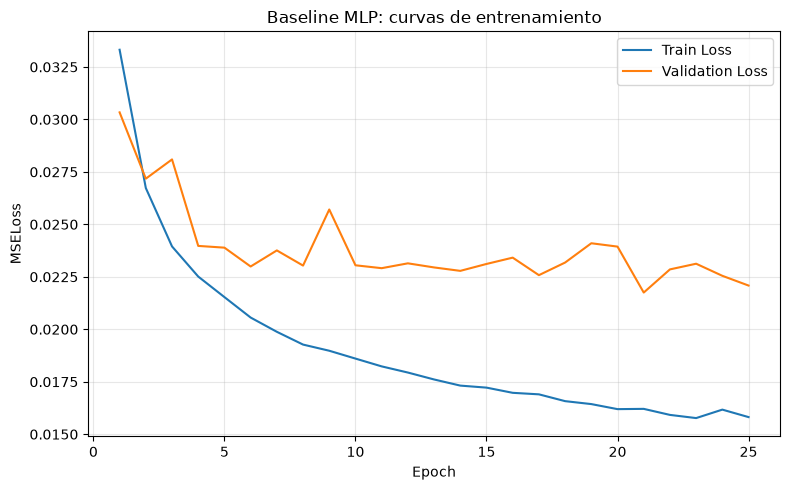

Gráfica guardada en C:\TFM_Codigo\TFM-VLA\images\baseline_mlp_loss.png


In [6]:
plt.figure(figsize=(8,5)); plt.plot([r['epoch'] for r in history],[r['train_loss'] for r in history],label='Train Loss'); plt.plot([r['epoch'] for r in history],[r['validation_loss'] for r in history],label='Validation Loss'); plt.xlabel('Epoch'); plt.ylabel('MSELoss'); plt.title('Baseline MLP: curvas de entrenamiento'); plt.grid(alpha=.3); plt.legend(); plt.tight_layout()
loss_plot_path=IMAGES_DIR/'baseline_mlp_loss.png'; plt.savefig(loss_plot_path,dpi=150); plt.show(); print(f'Gráfica guardada en {loss_plot_path}')

## 7. Evaluación sobre test

Se carga el mejor checkpoint y se calculan MAE, MSE, RMSE, similitud coseno, tiempo medio de inferencia y parámetros entrenables.

In [7]:
checkpoint=torch.load(best_path,map_location=DEVICE); model.load_state_dict(checkpoint['model_state_dict']); model.eval(); predicciones=[]; objetivos=[]
inference_start=time.perf_counter()
with torch.no_grad():
    for features,targets in loaders['test']:
        predicciones.append(model(features.to(DEVICE)).cpu()); objetivos.append(targets)
inference_time=time.perf_counter()-inference_start; y_pred=torch.cat(predicciones); y_true=torch.cat(objetivos); error=y_pred-y_true
mae=error.abs().mean().item(); mse=error.pow(2).mean().item(); rmse=mse**.5; cosine_similarity=torch.nn.functional.cosine_similarity(y_pred,y_true,dim=1).mean().item(); mean_inference_ms=inference_time/len(y_true)*1000
metrics={'MAE':mae,'MSE':mse,'RMSE':rmse,'cosine_similarity':cosine_similarity,'mean_inference_ms_per_sample':mean_inference_ms,'trainable_parameters':num_params}
print(json.dumps(metrics,indent=2,ensure_ascii=False))

{
  "MAE": 0.060865528881549835,
  "MSE": 0.021092301234602928,
  "RMSE": 0.14523188780224172,
  "cosine_similarity": 0.9652652740478516,
  "mean_inference_ms_per_sample": 0.17585208175854297,
  "trainable_parameters": 658184
}


## 8. Inspección de predicciones

Se imprimen diez muestras con acción real, acción predicha y error absoluto componente a componente.

In [8]:
for i in range(min(10,len(y_true))):
    print(f'Muestra {i+1}'); print('  Acción real:    ',np.round(y_true[i].numpy(),4)); print('  Acción predicha:',np.round(y_pred[i].numpy(),4)); print('  Error absoluto: ',np.round(error[i].abs().numpy(),4))

Muestra 1
  Acción real:     [0.     0.7644 0.5444 0.2721 0.4641 0.5407 0.254  1.    ]
  Acción predicha: [0.0353 0.7298 0.5776 0.3101 0.4592 0.5039 0.4162 1.0026]
  Error absoluto:  [0.0353 0.0346 0.0332 0.038  0.0049 0.0368 0.1622 0.0026]
Muestra 2
  Acción real:     [0.     0.773  0.5524 0.2559 0.3838 0.4283 0.1611 1.    ]
  Acción predicha: [0.0531 0.7256 0.5652 0.2765 0.4618 0.5117 0.3935 1.0057]
  Error absoluto:  [0.0531 0.0474 0.0128 0.0207 0.078  0.0834 0.2325 0.0057]
Muestra 3
  Acción real:     [0.     0.764  0.5611 0.2592 0.4349 0.4871 0.2034 1.    ]
  Acción predicha: [0.0493 0.7351 0.5605 0.2846 0.4641 0.5018 0.3899 0.9911]
  Error absoluto:  [0.0493 0.0288 0.0006 0.0254 0.0292 0.0146 0.1865 0.0089]
Muestra 4
  Acción real:     [0.     0.7595 0.5754 0.2049 0.461  0.6    0.2329 1.    ]
  Acción predicha: [0.052  0.7358 0.5587 0.2636 0.4633 0.5103 0.3905 0.9849]
  Error absoluto:  [0.052  0.0236 0.0167 0.0587 0.0023 0.0897 0.1576 0.0151]
Muestra 5
  Acción real:     [0.    

## 9. Resultados reutilizables

El JSON reúne configuración, historial y métricas para compararlo directamente con el Transformer.

In [9]:
resultado={'model':'BaselineMLP','input':'CLIP image (512) + CLIP text (512) concatenated','output_dim':8,'seed':SEED,'device':str(DEVICE),'batch_size':BATCH_SIZE,'learning_rate':LEARNING_RATE,'epochs_requested':EPOCHS,'dropout':DROPOUT,'best_epoch':best_epoch,'best_validation_loss':best_val_loss,'total_training_time_seconds':total_training_time,'test_metrics':metrics,'history':history,'artifacts':{'checkpoint':str(best_path),'loss_plot':str(loss_plot_path)}}
results_path=RESULTS_DIR/'baseline_mlp_results.json'
with results_path.open('w',encoding='utf-8') as archivo: json.dump(resultado,archivo,indent=2,ensure_ascii=False)
print(f'Resultados guardados en {results_path}'); print('Baseline MLP completado correctamente.')

Resultados guardados en C:\TFM_Codigo\TFM-VLA\results\baseline_mlp_results.json
Baseline MLP completado correctamente.
